# Docking


In [ ]:
sudo apt install texlive-latex-base texlive-fonts-recommended texlive-fonts-extra texlive-latex-extra


In [ ]:
# Prepare first protein using fasta from genebank by swiss model or retrieve directly from the pdb

In [ ]:
# Prepare the ligand using smiles from pubchem and translate it into pdb through cactus smile translator

In [ ]:
# if protein contain extra ligand then manually remove 

go to pymol upload protein select ligand > click right > remove it > save protein

In [ ]:
# run this code in to mgltools/bin file

In [ ]:
/MGLTools-1.5.7/bin/pythonsh /MGLTools-1.5.7/MGLToolsPckgs/AutoDockTools/Utilities24/prepare_gpf4.py -l /MGLTools-1.5.7/bin/acetyl_glucosamine.pdbqt -r /MGLTools-1.5.7/bin/5k14.pdbqt -o /acetyl_5k14.gpf                                                                    
/MGLTools-1.5.7/bin/pythonsh /MGLTools-1.5.7/MGLToolsPckgs/AutoDockTools/Utilities24/prepare_dpf4.py -l /MGLTools-1.5.7/bin/acetyl_glucosamine.pdbqt -r /MGLTools-1.5.7/bin/5k14.pdbqt -o /acetyl_5k14.dpf -p ga_num_evals=2000000 -p ga_run=20
autogrid4 -p /acetyl_5k14.gpf -l /acetyl_5k14.glg                                                                         
autodock4 -p /acetyl_5k14.dpf -l /acetyl_5k14.dlg



In [ ]:
/MGLTools-1.5.7/bin/pythonsh /MGLTools-1.5.7/MGLToolsPckgs/AutoDockTools/Utilities24/prepare_gpf4.py -l /MGLTools-1.5.7/bin/acetyl_glucosamine_noD.pdbqt -r /MGLTools-1.5.7/bin/5k14.pdbqt -o /acetyl_5k14.gpf                                                                    
/MGLTools-1.5.7/bin/pythonsh /MGLTools-1.5.7/MGLToolsPckgs/AutoDockTools/Utilities24/prepare_dpf4.py -l /MGLTools-1.5.7/bin/acetyl_glucosamine_noD.pdbqt -r /MGLTools-1.5.7/bin/5k14.pdbqt -o /acetyl_5k14.dpf -p ga_num_evals=2000000 -p ga_run=20
autogrid4 -p /acetyl_5k14.gpf -l /acetyl_5k14.glg                                                                         
autodock4 -p /acetyl_5k14.dpf -l /acetyl_5k14.dlg



In [ ]:
/dock_amber/mgltools_x86_64Linux2_1.5.7/bin/pythonsh /dock_amber/mgltools_x86_64Linux2_1.5.7/MGLToolsPckgs/AutoDockTools/Utilities24/prepare_gpf4.py -l /dock_amber/mgltools_x86_64Linux2_1.5.7/bin/acetyl_glucosamine_noD.pdbqt -r /dock_amber/mgltools_x86_64Linux2_1.5.7/bin/5k14.pdbqt -o sample.gpf
/dock_amber/mgltools_x86_64Linux2_1.5.7/bin/pythonsh /dock_amber/mgltools_x86_64Linux2_1.5.7/MGLToolsPckgs/AutoDockTools/Utilities24/prepare_dpf4.py -l /dock_amber/mgltools_x86_64Linux2_1.5.7/bin/acetyl_glucosamine_noD.pdbqt -r /dock_amber/mgltools_x86_64Linux2_1.5.7/bin/5k14.pdbqt -o sample.dpf -p ga_num_evals=2000000 -p ga_run=20                                                                                                   
autogrid4 -p sample.gpf -l sample.glg
autodock4 -p sample.dpf -l sample.dlg

## open autodock go to option analyse > docking > open > dlg > analyse > macromolecules > protein open > then go to analyse > confirmation > play, ranked by energy > select your owest energy no. > open panel to change play option left to play button sign > set play option > write complex > save file result as pdb file > then visualize result in the pymol


In [ ]:
# from here start simulation

In [ ]:

#gromcs installation
sudo apt update
sudo apt install build-essential cmake git

tar -xvzf gromacs-2025.3.tar.gz
cd gromacs-2025.3
mkdir build
cd build

sudo apt remove cmake
sudo snap install cmake --classic





In [ ]:
#optional if get problem

In [ ]:
# pymol
python
stored.leu_residues_missing_CG = []
for model in cmd.get_object_list():
    for resi in cmd.get_residues(f"resn LEU and model {model}"):
        atom_names = [atom.name for atom in cmd.get_model(f"model {model} and resi {resi} and resn LEU").atom]
        if 'CG' not in atom_names:
            stored.leu_residues_missing_CG.append((model, resi))
print("LEU residues missing CG atom:", stored.leu_residues_missing_CG)
python end


# Step1 convert pdbqt to pdb

In [ ]:
obabel -i pdbqt acetyl_5k14.pdbqt -o pdb -O raw.pdb


# Step 2 — Split Protein & Ligand

In [ ]:
grep -v "UNK" raw.pdb | grep "^ATOM" > protein_only.pdb

In [ ]:

# Ligand (only UNK atoms)
grep "UNK" complex_raw.pdb > ligand_only.pdb


In [ ]:
# Count ligand atoms
grep "^HETATM\|^ATOM" ligand_only.pdb | wc -l   # 23

In [ ]:
obabel ligand_only.pdb -O ligand_only.mol2 --gen3d


# Step 3 — Generate Ligand Topology with ACPYPE

In [ ]:
acpype -i ligand_only.mol2 -c user -n 0

# pdbfixer for protein

In [ ]:
pip install openmm
git clone https://github.com/openmm/pdbfixer.git
cd pdbfixer
python setup.py install
pip install pdb-tools
pdbfixer$ pdbfixer /dock_amber/protein_only.pdb --add-atoms=all --add-residues --replace-nonstandard --output=/dock_amber/protein.pdb


# Step 4 — Generate Protein Topology

In [ ]:

gmx pdb2gmx -f protein.pdb -o protein_processed.gro -p topol.top -water tip3p -ff amber99sb-ildn -ignh


# Step 5 — Combine Protein + Ligand

In [ ]:
cat protein_processed.gro ligand_only.acpype/ligand_only_GMX.gro > complex.gro


# Edit topol.top: include ligand after the forcefield line:

# include "ligand_only.acpype/ligand_only_GMX.itp"

# Step 6 — Define Simulation Box

In [ ]:
gmx editconf -f complex.gro -o boxed.gro -c -d 1.0 -bt cubic


# Step 7 — Solvate

In [ ]:
gmx solvate -cp boxed.gro -cs spc216.gro -o solv.gro -p topol.top



# Step 8 — Prepare Ions
### Create ions.mdp with minimal settings:
### integrator  = steep
### emtol       = 1000.0
### emstep      = 0.01
### nsteps      = 500
### nstlist     = 10
### cutoff-scheme = Verlet
### coulombtype = PME
### rcoulomb    = 1.0
### rvdw        = 1.0
### pbc         = xyz

# Step 9 — Generate TPR for Ions

In [ ]:
gmx grompp -f ions.mdp -c solv.gro -p topol.top -o ions.tpr -maxwarn 
or
gmx grompp -f ions.mdp -c solv.gro -p topol.top -o ions.tpr -maxwarn 2


# Step 10 — Add Ions

In [ ]:
gmx genion -s ions.tpr -o solv_ions.gro -p topol.top -pname NA -nname CL -neutral

# Step 11 — Energy Minimization
### Create minim.mdp:
### integrator = steep
### emtol = 1000.0
### emstep = 0.01
### nsteps = 50000
### nstlist = 10
### cutoff-scheme = Verlet
### ns_type = grid
### coulombtype = PME
### rcoulomb = 1.0
### rvdw = 1.0
### pbc = xyz

In [ ]:
conda create -n gmx_env -c conda-forge gromacs=2025
conda activate gmx_env


In [ ]:
gmx grompp -f minim.mdp -c solv_ions.gro -p topol.top -o em.tpr -maxwarn 1
systemd-run --scope -p MemoryMax=100G \
gmx mdrun -v -deffnm em -nt 20 -pin on

# .xvg for visualize energy through plot

In [ ]:
gmx energy -f em.edr -o potential.xvg


In [ ]:
gmx make_ndx -f em.gro -o index.ndx
# here select 1 | 13
# and q for save and exit

# Step 12 — Equilibration
### here also create nvt.mdp with 1 nanosec time
# NVT

In [ ]:
gmx grompp -f nvt.mdp -c em.gro -r em.gro -p topol.top -o nvt.tpr
systemd-run --scope -p MemoryMax=100G \
gmx mdrun -deffnm nvt -nt 20 -pin on
# or#
gmx mdrun -deffnm nvt -nt 4


In [ ]:
gmx energy -f nvt.edr
 
select 15 17 13 11 12

for  

Potential                -3.25037e+06       2900    38846.3      16640  (kJ/mol)
Kinetic En.                  634335       2200    30800.2    13019.3  (kJ/mol)
Total Energy             -2.61604e+06       5000    69240.4    29659.3  (kJ/mol)
Temperature                 299.028          1    14.5193    6.13738  (K)
Pressure                   -197.752        3.8    242.928     1.7067  (bar)

this will give .xvg file

Matplotlib is building the font cache; this may take a moment.


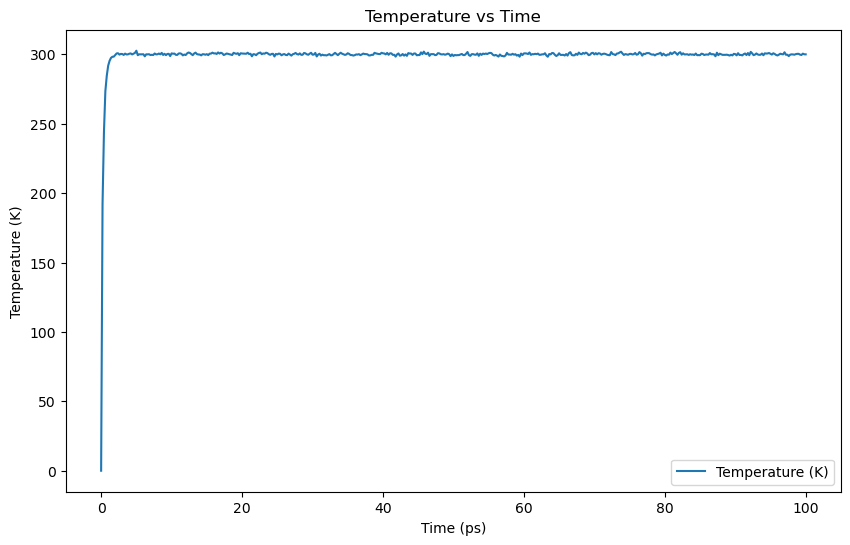

In [1]:
import matplotlib.pyplot as plt

# Load data, skipping lines starting with '@' or '#'
data = []
with open('/dock_amber/energy.xvg', 'r') as f:
    for line in f:
        if not (line.startswith('@') or line.startswith('#')):
            data.append([float(x) for x in line.split()])

# Transpose the data columns
data = list(zip(*data))
time = data[0]
potential_energy = data[1]
kinetic_energy = data[2]
total_energy = data[3]
temperature = data[4]
pressure = data[5]

plt.figure(figsize=(10, 6))
plt.plot(time, temperature, label='Temperature (K)')
plt.xlabel('Time (ps)')
plt.ylabel('Temperature (K)')
plt.title('Temperature vs Time')
plt.legend()
plt.show()


# NPT (100 ps)

In [ ]:
gmx grompp -f npt.mdp -c nvt.gro -r nvt.gro -t nvt.cpt -p topol.top -o npt.tpr
systemd-run --scope -p MemoryMax=100G \
gmx mdrun -deffnm npt -nt 20 -pin on

gmx mdrun -deffnm npt -nt 4

In [ ]:
gmx energy -f npt.edr -o pressure.xvg

gmx energy -f npt.edr -o density.xvg


In [ ]:
select 11 12 13 15 17 22 23 0


Energy                      Average   Err.Est.       RMSD  Tot-Drift
-------------------------------------------------------------------------------
Potential                -3.25611e+06        320    1918.13   -1532.14  (kJ/mol)
Kinetic En.                  636457         39    1362.18   -3.44564  (kJ/mol)
Total Energy             -2.61965e+06        350    2476.33   -1535.59  (kJ/mol)
Temperature                 300.028      0.018   0.642135 -0.00162605  (K)
Pressure                   -3.90511          5      49.84    28.9321  (bar)
Volume                      2521.97       0.86    3.77892   -3.22386  (nm^3)
Density                     1004.14       0.34    1.49573    1.27323  (kg/m^3)

GROMACS reminds you: "Where all think alike, no one thinks very much." (Walter Lippmann)



# step 13 Production MD

In [ ]:
gmx grompp -f 100ns.mdp -c npt.gro -t npt.cpt -p topol.top -o md_100ns.tpr
systemd-run --scope -p MemoryMax=100G \
gmx mdrun -deffnm md_100ns -nt 20 -pin on

 # post-processing 

In [ ]:
gmx trjconv -s npt.gro -f md_100ns.trr -o traj.xtc
  

In [ ]:
gmx grompp -f ligand_only.acpype/md.mdp -c npt.gro -p topol.top -o topol.tpr

In [ ]:
gmx trjconv -s topol.tpr -f solvated_ions.pdb -o compact.pdb -ur compact -pbc mol


# Protein-Ligand Hydrogen Bonding Interactions


In [ ]:
gmx hbond -f npt.trr -s npt.tpr -num hbond.xvg


In [ ]:
gmx energy -f md_100ns.edr -o vdw.xvg

gmx energy -f md_100ns.edr -o  es.xvg

# RMSD

In [ ]:
gmx rms -s md_100ns.tpr -f traj.xtc -o rmsd.xvg -tu ns


# RMSF

In [ ]:
gmx rmsf -s md_100ns.tpr -f traj.xtc -o rmsf.xvg 


# Radius of Gyration, Rg
